In [17]:
# -*- coding: utf-8 -*-

import os
import pandas as pd
import matplotlib.pyplot as plt

# 기본 경로 (필요시 바꾸세요)
BASE_DIR = os.path.expanduser('~/ros2_ws/src/test_truck/real')
FILES = [
    ('Truck 0', os.path.join(BASE_DIR, '0_truck.csv')),
    ('Truck 1', os.path.join(BASE_DIR, '1_truck.csv')),
    ('Truck 2', os.path.join(BASE_DIR, '2_truck.csv')),
]

def load_csv(path):
    """CSV 로드: timestamp,x,y,velocity,pitch 헤더 가정"""
    if not os.path.exists(path):
        raise FileNotFoundError(f"CSV not found: {path}")
    df = pd.read_csv(path)
    # 컬럼 존재 체크 및 타입 변환
    for col in ['timestamp', 'x', 'y', 'velocity']:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' missing in {path}")
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['x'] = pd.to_numeric(df['x'], errors='coerce')
    df['y'] = pd.to_numeric(df['y'], errors='coerce')
    df['velocity'] = pd.to_numeric(df['velocity'], errors='coerce')
    df = df.dropna(subset=['timestamp', 'x', 'y', 'velocity']).reset_index(drop=True)
    # 시작 시점을 0초로 정규화(보기 편하게)
    if len(df) > 0:
        t0 = df['timestamp'].iloc[0]
        df['t_rel'] = df['timestamp'] - t0
    else:
        df['t_rel'] = df['timestamp']
    return df

def plot_xy(dfs):
    """x-y 궤적을 하나의 그림에 플롯 (트럭 3대).
    t_rel ∈ [150, 210] 초 구간만 굵게 강조"""
    plt.figure(figsize=(16, 16))
    #for detail
    #plt.figure(figsize=(120, 120))
    for idx, (name, df) in enumerate(dfs):
        if len(df) == 0:
            continue

        # 트럭 번호로 zorder 결정 (Truck1이 가장 위)
        # Truck 1 -> zorder=3, Truck 2 -> zorder=2, Truck 3 -> zorder=1
        z = 3 - idx -1

        # 전체 궤적: 얇고 투명하게
        line, = plt.plot(df['x'], df['y'], label=name, alpha=0.3,
                         linewidth=1, zorder=z)
        base_color = line.get_color()

        #150~210초 구간만 굵게 강조
        # if 't_rel' in df.columns:
        #     mask = (df['t_rel'] >= 150) & (df['t_rel'] <= 210)
        #     seg = df[mask]
        #     if not seg.empty:
        #         plt.plot(seg['x'], seg['y'],
        #                  color=base_color, linewidth=3,
        #                  label=f"{name} (150–210 s)", zorder=z)

    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.xlim(18800, 19700)

    #for detail
    #plt.xlim(19500, 19510)
    #plt.ylim(17400, 18250)
    plt.title('Truck Trajectories (X-Y)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.tight_layout()


def plot_speed_time(dfs):
    """속도-시간 그래프(상대시간 t_rel, 초)"""
    plt.figure()
    for name, df in dfs:
        if len(df) == 0:
            continue
        plt.plot(df['t_rel'], df['velocity']*3.6, label=name)
    plt.xlabel('Time (s)')
    plt.ylabel('Speed (km/h)')
    plt.title('Truck Speed')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # 저장도 원하면 주석 해제
    # plt.savefig(os.path.join(BASE_DIR, 'speed_time.png'), dpi=200)

def main():
    # CSV 로드
    dfs = []
    for name, path in FILES:
        try:
            df = load_csv(path)
            dfs.append((name, df))
            print(f"Loaded {name}: {len(df)} rows from {path}")
        except Exception as e:
            print(f"[WARN] {name} skipped: {e}")

    if not dfs:
        print("No data to plot. Check CSV paths.")
        return

    # 1) x-y 궤적
    plot_xy(dfs)
    # 2) 속도-시간
    plot_speed_time(dfs)

    # 화면 표시
    plt.show()

if __name__ == '__main__':
    main()


[WARN] Truck 0 skipped: CSV not found: /home/avees/ros2_ws/src/test_truck/real/0_truck.csv
[WARN] Truck 1 skipped: CSV not found: /home/avees/ros2_ws/src/test_truck/real/1_truck.csv
[WARN] Truck 2 skipped: CSV not found: /home/avees/ros2_ws/src/test_truck/real/2_truck.csv
No data to plot. Check CSV paths.


Loaded Truck 0: 5056 rows from /home/avees/ros2_ws/src/test_truck/plot/0_truck.csv
Loaded Truck 1: 5053 rows from /home/avees/ros2_ws/src/test_truck/plot/1_truck.csv
Loaded Truck 2: 5044 rows from /home/avees/ros2_ws/src/test_truck/plot/2_truck.csv


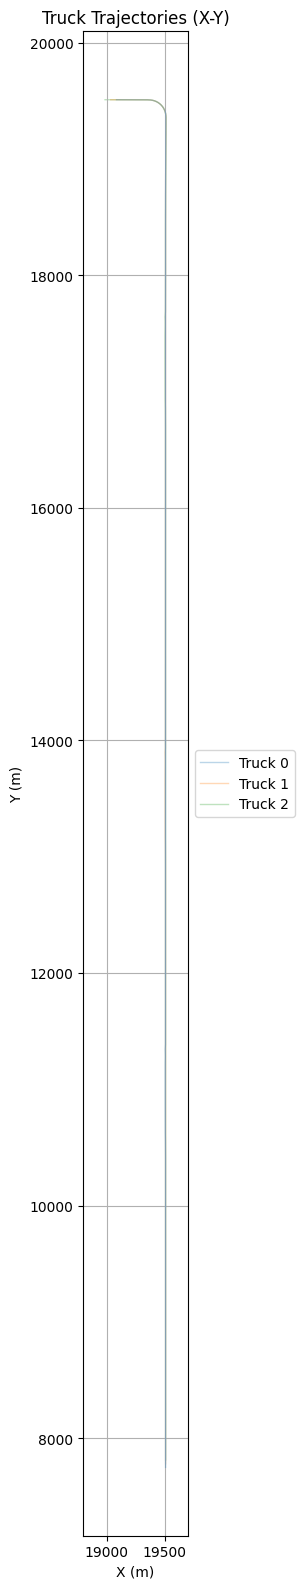

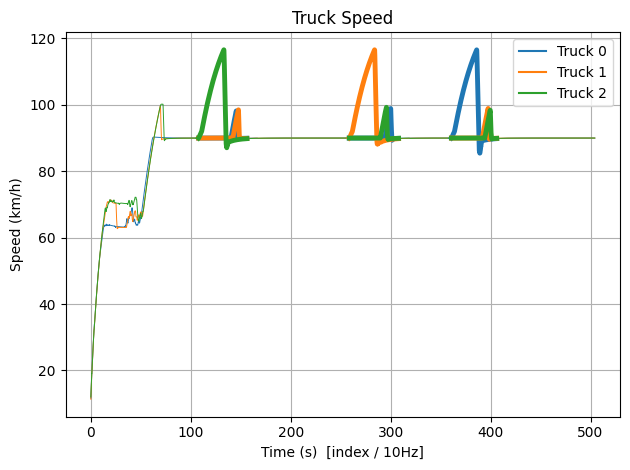

In [20]:
# -*- coding: utf-8 -*-

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 기본 경로 (필요시 바꾸세요)
BASE_DIR = os.path.expanduser('~/ros2_ws/src/test_truck/plot')
FILES = [
    ('Truck 0', os.path.join(BASE_DIR, '0_truck.csv')),
    ('Truck 1', os.path.join(BASE_DIR, '1_truck.csv')),
    ('Truck 2', os.path.join(BASE_DIR, '2_truck.csv')),
]

HZ = 10.0  # 10Hz 고정

def _coerce_numeric(s):
    return pd.to_numeric(s, errors='coerce')

def load_csv(path):
    """필수: x,y,velocity. formation_change: 있으면 사용, 없으면 6번째 열 시도."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"CSV not found: {path}")
    df = pd.read_csv(path)

    for col in ['x', 'y', 'velocity']:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' missing in {path}")

    df['x'] = _coerce_numeric(df['x'])
    df['y'] = _coerce_numeric(df['y'])
    df['velocity'] = _coerce_numeric(df['velocity'])

    if 'formation_change' in df.columns:
        df['formation_change'] = _coerce_numeric(df['formation_change'])
    else:
        if df.shape[1] >= 6:
            sixth = df.columns[5]
            df['formation_change'] = _coerce_numeric(df[sixth])
        else:
            df['formation_change'] = 0.0  # 없으면 전부 0 취급

    df = df.dropna(subset=['x', 'y', 'velocity']).reset_index(drop=True)
    df['fc_bool'] = df['formation_change'].fillna(0) != 0
    return df

def plot_xy(dfs):
    """x-y 궤적 플롯(이 부분은 인덱스 독립)."""
    plt.figure(figsize=(16, 16))
    for idx, (name, df) in enumerate(dfs):
        if len(df) == 0:
            continue
        z = 3 - idx - 1
        plt.plot(df['x'], df['y'], label=name, alpha=0.3, linewidth=1, zorder=z)
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.xlim(18800, 19700)
    plt.title('Truck Trajectories (X-Y)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.tight_layout()

def _intervals_from_mask(mask):
    """불리언 1D 마스크에서 True 연속구간을 (s,e) 인덱스 쌍으로 반환. e 포함."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    padded = np.r_[False, mask, False]
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0] - 1
    return list(zip(starts, ends))

def plot_speed_time_indexed(dfs):
    """인덱스(10Hz) 기준:
       - any(fc)!=0 구간: 굵은 실선
       - all(fc)==0 구간: 보통 실선
       세 파일 공통 길이까지만 사용.
    """
    # 공통 길이
    common_len = min((len(df) for _, df in dfs if len(df) > 0), default=0)
    if common_len == 0:
        print("No data to plot in common range.")
        return

    # 시간축 = 인덱스/HZ
    t = np.arange(common_len) / HZ

    # fc 합집합 마스크(any)와 보수(all-zero)
    fc_stack = []
    for _, df in dfs:
        fc_stack.append(np.asarray(df['fc_bool'][:common_len], dtype=bool))
    fc_stack = np.vstack(fc_stack)                  # (n_files, common_len)
    any_fc = fc_stack.any(axis=0)                   # 하나라도 True
    # all-zero는 any_fc의 부정으로 처리. 인덱스 기준 요구사항과 일치.
    zero_fc = ~any_fc

    # 라인 색 고정
    plt.figure()
    metas = []
    for name, df in dfs:
        line, = plt.plot([], [], label=name)  # 색만 받아오기
        metas.append((name, df, line.get_color()))

    # 먼저 all-zero 구간을 보통 두께로 그림
    zero_ints = _intervals_from_mask(zero_fc)
    for name, df, color in metas:
        v = df['velocity'].to_numpy()[:common_len] * 3.6
        for s, e in zero_ints:
            plt.plot(t[s:e+1], v[s:e+1], color=color, linewidth=0.7)

    # any-nonzero 구간을 굵게 overplot
    hi_ints = _intervals_from_mask(any_fc)
    for name, df, color in metas:
        v = df['velocity'].to_numpy()[:common_len] * 3.6
        for s, e in hi_ints:
            plt.plot(t[s:e+1], v[s:e+1], color=color, linewidth=3.5)

    plt.xlabel('Time (s)  [index / 10Hz]')
    plt.ylabel('Speed (km/h)')
    plt.title('Truck Speed')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def main():
    dfs = []
    for name, path in FILES:
        try:
            df = load_csv(path)
            dfs.append((name, df))
            print(f"Loaded {name}: {len(df)} rows from {path}")
        except Exception as e:
            print(f"[WARN] {name} skipped: {e}")

    if not dfs:
        print("No data to plot. Check CSV paths.")
        return

    plot_xy(dfs)
    plot_speed_time_indexed(dfs)
    plt.show()

if __name__ == '__main__':
    main()
